# 5-Fold Data Splitting

This notebook creates 5-fold cross-validation splits for insurance modeling data.

**Steps:**
1. Load and merge data
2. Remove zero exposure records
3. Calculate Pure Premium
4. Run simulations to find optimal seed
5. Apply best seed and validate
6. Save output

## 1. Setup and Imports

In [15]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import functions from utils.py
from utils import (
    load_and_merge_data,
    remove_zero_exposure,
    calculate_pure_premium,
    calculate_overall_stats,
    print_overall_stats,
    run_simulations,
    get_best_seed,
    plot_objective_distribution,
    assign_folds,
    validate_folds,
    save_output
)

# Import config
from config import (
    MAIN_DATA_PATH, SUPERPOLICY_PATH, OUTPUT_PATH,
    N_SIMULATIONS, N_FOLDS
)

print("Imports complete!")
print(f"\nConfiguration:")
print(f"  Main data: {MAIN_DATA_PATH}")
print(f"  Superpolicy: {SUPERPOLICY_PATH}")
print(f"  Output: {OUTPUT_PATH}")
print(f"  Simulations: {N_SIMULATIONS}")
print(f"  Folds: {N_FOLDS}")

Imports complete!

Configuration:
  Main data: /Users/Mach/dev/aps/data/2026_Dmodel_data/master_dataset_car.parquet
  Superpolicy: /Users/Mach/dev/aps/data/2026_Dmodel_data/superpolicy/superpolicy_car.parquet
  Output: /Users/Mach/dev/aps/data/2026_Dmodel_data/fold_superpolicy/car_master_dataset_fold_sp.parquet
  Simulations: 100
  Folds: 5


## 2. Load and Merge Data

In [16]:
# Load main data and superpolicy data, merge on vin_date
df = load_and_merge_data()

LOADING DATA

Loading main data from:
  /Users/Mach/dev/aps/data/2026_Dmodel_data/master_dataset_car.parquet
  Main data shape: (22705842, 13)

Loading superpolicy data from:
  /Users/Mach/dev/aps/data/2026_Dmodel_data/superpolicy/superpolicy_car.parquet
  Superpolicy data shape: (22705842, 2)

Merging on 'vin_date'...
  Merged data shape: (22705842, 14)


In [17]:
# Quick look at the data
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Shape: (22705842, 14)

Columns: ['vin_date', 'ee_bi_raw', 'ee_pd_raw', 'ee_pip_raw', 'ee_med_raw', 'ee_coll_imps', 'ee_comp_raw', 'incurred_raw_bi_imps', 'incurred_raw_pd_imps', 'incurred_raw_pip_imps', 'incurred_raw_med_cal_imps', 'incurred_raw_coll_imps', 'incurred_raw_comp_imps', 'superpolicy_id']


,vin_date,ee_bi_raw,ee_pd_raw,ee_pip_raw,ee_med_raw,ee_coll_imps,ee_comp_raw,incurred_raw_bi_imps,incurred_raw_pd_imps,incurred_raw_pip_imps,incurred_raw_med_cal_imps,incurred_raw_coll_imps,incurred_raw_comp_imps,superpolicy_id
0,KMHWF35H45A178516_04-26-2022,1.000000,1.000000,0.000000,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0
1,KMHWF35H75A128502_11-21-2020,0.117501,0.117501,0.000000,NaN,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1
2,KMHD35LE5DU068088_05-03-2020,0.155738,0.155738,0.000000,NaN,0.155738,0.155738,0.0,0.0,0.0,0.0,0.0,0.0,2
3,KMHD35LE5DU047158_05-30-2021,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,3
4,KMHD35LE5DU082332_11-17-2019,0.497605,0.497605,0.497605,NaN,0.497605,0.497605,0.0,0.0,0.0,0.0,0.0,0.0,4


## 2b. Explore Exposure Distributions (Optional)

In [18]:
# Check what columns are available in the original data
# to see if there are raw versions (ee_bi_raw, etc.)
import pyarrow.parquet as pq

# Read just the schema (no data loading)
parquet_file = pq.ParquetFile(MAIN_DATA_PATH)
all_columns = parquet_file.schema.names

# Show all columns with 'ee' in the name
print("All EE-related columns in the data:")
ee_related = [c for c in all_columns if 'ee_' in c.lower()]
for col in sorted(ee_related):
    print(f"  {col}")

All EE-related columns in the data:
  ee_bi_imps
  ee_bi_raw
  ee_coll_imp_imps
  ee_coll_imps
  ee_comp_imps
  ee_comp_raw
  ee_imps
  ee_med_imps
  ee_med_raw
  ee_pd_imps
  ee_pd_raw
  ee_pip_imps
  ee_pip_raw
  ee_raw
  ee_uim_imps
  ee_uim_raw
  ee_um_imps
  ee_um_raw


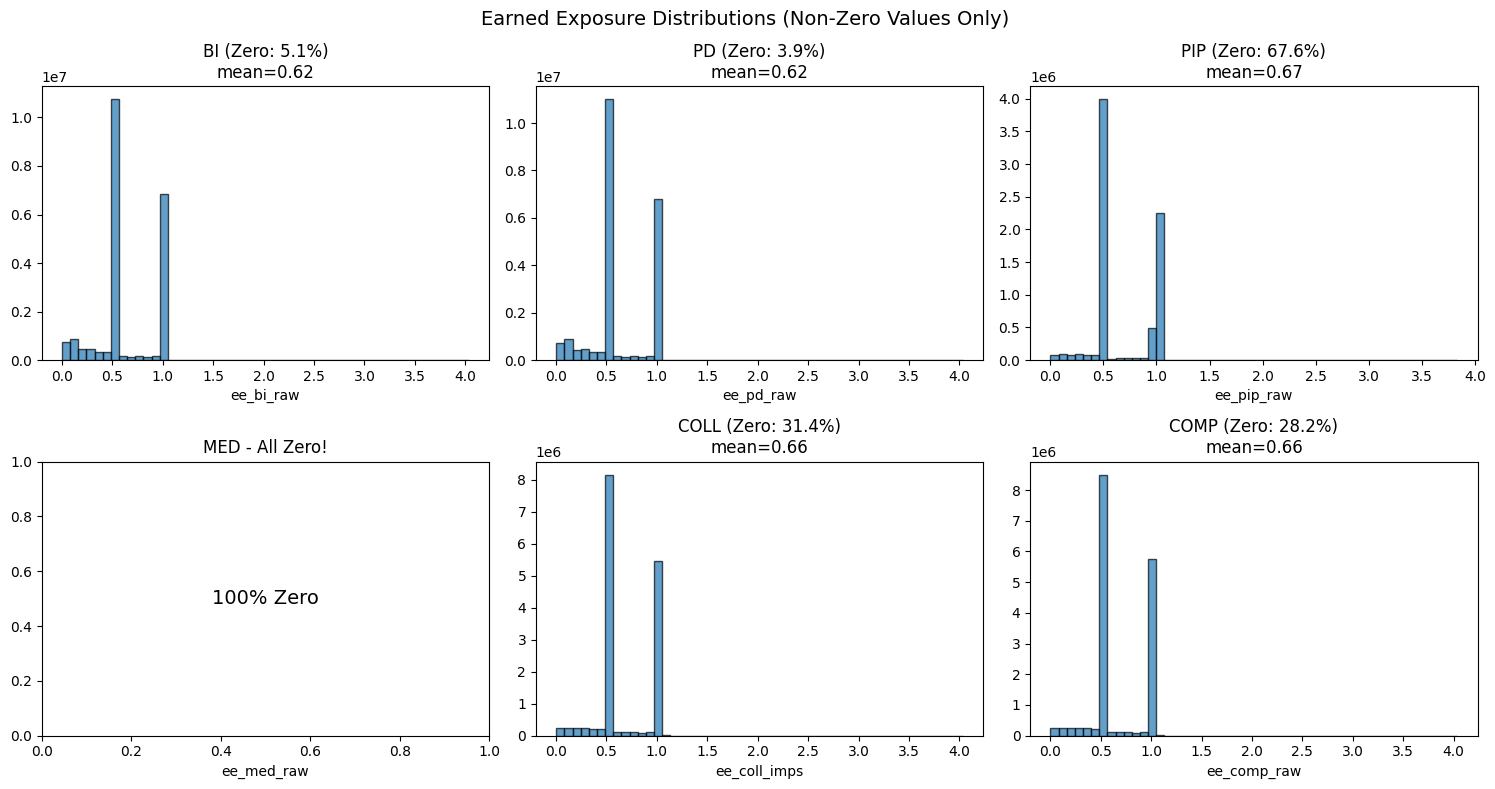


Summary of zero exposure:
  BI   : 1,148,364 zeros (5.1%)
  PD   : 894,590 zeros (3.9%)
  PIP  : 15,343,095 zeros (67.6%)
  MED  : 2,201,917 zeros (9.7%)
  COLL : 7,123,525 zeros (31.4%)
  COMP : 6,411,168 zeros (28.2%)


In [19]:
# Plot histograms of all EE columns to understand distributions
from config import EE_COLUMNS

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (cov, col) in enumerate(EE_COLUMNS.items()):
    ax = axes[i]
    
    # Get data
    data = df[col]
    
    # Stats
    zero_count = (data == 0).sum()
    zero_pct = 100 * zero_count / len(data)
    nonzero_data = data[data > 0]
    
    # Plot non-zero values only
    if len(nonzero_data) > 0:
        ax.hist(nonzero_data, bins=50, edgecolor='black', alpha=0.7)
        ax.set_title(f"{cov.upper()} (Zero: {zero_pct:.1f}%)\nmean={nonzero_data.mean():.2f}")
    else:
        ax.text(0.5, 0.5, f"100% Zero", ha='center', va='center', transform=ax.transAxes, fontsize=14)
        ax.set_title(f"{cov.upper()} - All Zero!")
    
    ax.set_xlabel(col)

plt.suptitle('Earned Exposure Distributions (Non-Zero Values Only)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nSummary of zero exposure:")
for cov, col in EE_COLUMNS.items():
    zero_count = (df[col] == 0).sum()
    zero_pct = 100 * zero_count / len(df)
    print(f"  {cov.upper():5s}: {zero_count:,} zeros ({zero_pct:.1f}%)")

In [ ]:
# Plot histograms of all INCURRED columns to understand distributions
from config import INCURRED_COLUMNS

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (cov, col) in enumerate(INCURRED_COLUMNS.items()):
    ax = axes[i]
    
    # Get data
    data = df[col]
    
    # Stats
    zero_count = (data == 0).sum()
    zero_pct = 100 * zero_count / len(data)
    nonzero_data = data[data > 0]
    
    # Plot non-zero values only
    if len(nonzero_data) > 0:
        ax.hist(nonzero_data, bins=50, edgecolor='black', alpha=0.7, color='orange')
        ax.set_title(f"{cov.upper()} (Zero: {zero_pct:.1f}%)\nmean={nonzero_data.mean():.2f}")
    else:
        ax.text(0.5, 0.5, f"100% Zero", ha='center', va='center', transform=ax.transAxes, fontsize=14)
        ax.set_title(f"{cov.upper()} - All Zero!")
    
    ax.set_xlabel(col)

plt.suptitle('Incurred Loss Distributions (Non-Zero Values Only)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nSummary of zero incurred:")
for cov, col in INCURRED_COLUMNS.items():
    zero_count = (df[col] == 0).sum()
    zero_pct = 100 * zero_count / len(df)
    print(f"  {cov.upper():5s}: {zero_count:,} zeros ({zero_pct:.1f}%)")

### Decision Point: Which coverages to use?

Based on the above analysis:
- If a coverage has 100% zero (like MED), consider **excluding it** from the objective function
- If raw columns exist (`ee_bi_raw`), consider using those instead of imputed (`ee_bi_imps`)
- High zero percentages (>50%) may indicate optional coverages not available in all states

**To exclude a coverage**, edit `config.py` and remove it from `COVERAGES`, `EE_COLUMNS`, and `INCURRED_COLUMNS`

## 3. Remove Zero Exposure Records

In [ ]:
# Remove records where any exposure column is zero
df = remove_zero_exposure(df)

In [ ]:
# Verify cleaned data
print(f"Cleaned data shape: {df.shape}")
df.head()

## 4. Calculate Pure Premium

In [ ]:
# Calculate Pure Premium for each coverage
df = calculate_pure_premium(df)

In [ ]:
# Calculate overall statistics (needed for objective function)
overall_stats = calculate_overall_stats(df)
print_overall_stats(overall_stats)

## 5. Run Simulations to Find Optimal Seed

In [ ]:
# Run simulations (100 seeds by default)
# This may take a few minutes depending on data size
results_df = run_simulations(df, overall_stats)

In [ ]:
# View simulation results
results_df.head(10)

## 6. View Objective Function Distribution

In [ ]:
# Plot histogram of objective function values
plot_objective_distribution(results_df)

In [ ]:
# Find the best seed
best_seed, best_obj = get_best_seed(results_df)

## 7. Apply Best Seed and Assign Folds

In [ ]:
# Assign folds using the best seed
df = assign_folds(df, best_seed)

print(f"\nFold distribution:")
print(df['fold'].value_counts().sort_index())

## 8. Validate Fold Assignment

In [ ]:
# Validate the fold assignment quality
validate_folds(df, overall_stats)

## 9. Save Output

In [ ]:
# Save fold assignments and simulation results
df_output = save_output(df, simulation_results=results_df)

In [ ]:
# Preview final output
print(f"\nOutput preview:")
df_output.head(10)

## Done!

The fold assignments have been saved. You can now merge this output back to your original data using `vin_date` as the join key.

In [ ]:
# Example: How to merge back to original data
# original_data = pd.read_parquet("your_original_data.parquet")
# merged = pd.merge(original_data, df_output[['vin_date', 'fold']], on='vin_date', how='left')